In [4]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
import random

In [5]:
def incidence_matrix(edges, nodes):

    num_edges = len(edges)
    num_nodes = len(nodes)
    
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    delta = np.zeros((num_edges, num_nodes), dtype=int)
    
    for i, (u, v) in enumerate(edges):
        delta[i, node_to_idx[u]] = -1
        delta[i, node_to_idx[v]] = 1
    
    
    return delta, node_to_idx

In [6]:
def solve_laplacian(delta, A, U, K, P, p_0, F):
    L = delta.T@A@K@delta
    N = L.shape[0]
    rhs = delta.T@A@U + F - F
     
    L_bar = L[1:, 1:]
    rhs_bar = rhs[1:] - L[1:, 0] * p_0
    P_bar = np.linalg.solve(L_bar, rhs_bar)

    P = np.zeros(N)
    P[0] = p_0
    P[1:] = P_bar

    return P, L

In [7]:
def solve_laplacian(delta, A, B, V, K, P, p_0, theta):
    
    Q_s = ((1 - theta) * B + theta * A) * V
    L = delta.T@K@delta
    N = L.shape[0]
    
    rhs = delta.T@Q_s
     
    L_bar = L[1:, 1:]
    rhs_bar = rhs[1:] - L[1:, 0] * p_0
    P_bar = np.linalg.solve(L_bar, rhs_bar)

    P = np.zeros(N)
    P[0] = p_0
    P[1:] = P_bar

    return P, L

In [8]:
def calculate_flow(delta, A, B, K, V, P, theta):
    K_1D = np.diag(K) if K.ndim == 2 else K    # force 1D
    Q_s = ((1 - theta) * B + theta * A) * V
    Q_w = Q_s - K_1D * (delta @ P)
    return Q_w

In [9]:
def calculate_core_flow(delta, A, K, V, P):
    K_1D = np.diag(K) if K.ndim == 2 else K
    Q_inner = A**2 * V - K_1D * (delta @ P)
    Q_inner = A * V - K_1D * (delta @ P)
    return Q_inner

In [10]:
def calculate_outer_flow(A, B, V, theta):
    Q_annulus = V * ((1-theta)*B + theta*A - A**2)
    Q_annulus = V * ((1-theta)*(B-A))
    return Q_annulus

In [11]:
def compute_lipid_flows(G, edges, node_to_idx, Q_total):
    """
    Computes lipid flow on each edge by the 50/50 equipartition rule.
    Q_total is the total lipid flow entering the network at the root.
    Returns Q_lipid: array of lipid flow rates per edge.
    """
    num_edges = len(edges)
    Q_lipid = np.zeros(num_edges)
    
    # uses memo to count the number of leaves in the network
    memo = {}
    def count_leaves(node):
        # checks if the node has already been counted (counters loops)
        if node in memo:
            return memo[node]
        children = list(G.successors(node))
        if len(children) == 0:
            memo[node] = 1
        else:
            memo[node] = sum(count_leaves(c) for c in children)
        return memo[node]
    
    total_leaves = count_leaves(0)
    
    for e_idx, (i, j) in enumerate(edges):
        downstream = count_leaves(j)
        Q_lipid[e_idx] = Q_total * downstream / total_leaves
    
    return Q_lipid

**BUILDING COMPLEX NETWORKS**

In [12]:
def _point_segment_closest(px, py, ax, ay, bx, by):
    """Closest point on segment AB to P; returns (dist, qx, qy, t) with t in [0,1]."""
    abx, aby = bx - ax, by - ay
    apx, apy = px - ax, py - ay
    ab2 = abx * abx + aby * aby
    if ab2 < 1e-18: # tolerance for zero length edge
        return np.hypot(apx, apy), ax, ay, 0.0
    t = (apx * abx + apy * aby) / ab2
    t = max(0.0, min(1.0, t))
    qx, qy = ax + t * abx, ay + t * aby
    return np.hypot(px - qx, py - qy), qx, qy, t

In [13]:

def try_attach_tip_to_network(
    px,
    py,
    anchor,
    seg_len,
    area,
    G,
    pos,
    area_values,
    direction,
    num_nodes,
    step,
    attach_thresh,
    fusion_min_accum,
):
    """If the tip lies near an existing vertex or edge, connect, anastomose, and stop this tip.

    Returns (attached: bool, num_nodes).
    """
    if attach_thresh <= 0:
        return False, num_nodes

    best_d = attach_thresh
    mode = None  # ('node', n) or ('edge', u, v, qx, qy, t)

    for n in G.nodes():
        if n == anchor:
            continue
        nx_, ny_ = pos[n]
        d = np.hypot(px - nx_, py - ny_)
        if d < best_d:
            if G.has_edge(anchor, n) or G.has_edge(n, anchor):
                continue
            best_d = d
            mode = ("node", n)

    for u, v in G.edges():
        if anchor in (u, v) and seg_len < fusion_min_accum:
            continue
        ax_, ay_ = pos[u]
        bx_, by_ = pos[v]
        d, qx, qy, t = _point_segment_closest(px, py, ax_, ay_, bx_, by_)
        # Interior hit on an edge incident to anchor would duplicate u→join or break direction; use vertex pass.
        if anchor in (u, v) and 1e-6 < t < 1.0 - 1e-6:
            continue
        if d >= best_d:
            continue
        # if near an endpoint let the vertex test handle it
        if t <= 1e-6 or t >= 1.0 - 1e-6:
            continue
        best_d = d
        mode = ("edge", u, v, qx, qy, t)

    if mode is None:
        return False, num_nodes

    cond_a = np.random.uniform(0.4, 0.7)
    run_L = max(seg_len + best_d, step)

    if mode[0] == "node":
        n = mode[1]
        G.add_edge(anchor, n, A=area, K=cond_a, L=run_L)
        return True, num_nodes

    _, u, v, qx, qy, t = mode
    data = G[u][v]
    L_old, A_e, K_e = data["L"], data["A"], data["K"]
    ax_, ay_ = pos[u]
    bx_, by_ = pos[v]
    geom = np.hypot(bx_ - ax_, by_ - ay_)
    if geom < 1e-12:
        return False, num_nodes
    dist_u = np.hypot(qx - ax_, qy - ay_)
    dist_v = np.hypot(bx_ - qx, by_ - qy)
    L_u = max(L_old * (dist_u / geom), step)
    L_v = max(L_old * (dist_v / geom), step)

    G.remove_edge(u, v)
    join = num_nodes
    pos[join] = (qx, qy)
    direction[join] = (0.0, 0.0)
    area_values[join] = np.random.uniform(0.1, 0.3)
    G.add_node(join)
    num_nodes += 1

    G.add_edge(u, join, A=A_e, K=K_e, L=L_u)
    G.add_edge(join, v, A=A_e, K=K_e, L=L_v)
    G.add_edge(anchor, join, A=area, K=cond_a, L=run_L)
    return True, num_nodes

In [14]:
def _segments_intersect(ax, ay, bx, by, cx, cy, dx_, dy_):
    # check if two line segments intersect
    def orient(px, py, qx, qy, rx, ry):
        # returns the orientation of the triplet 
        return (qx - px) * (ry - py) - (qy - py) * (rx - px)

    def on_segment(px, py, qx, qy, rx, ry):
        # check if point rx, ry lies on the line segment px, py - qx, qy
        return (
            min(px, qx) - 1e-12 <= rx <= max(px, qx) + 1e-12
            and min(py, qy) - 1e-12 <= ry <= max(py, qy) + 1e-12
        )

    o1 = orient(ax, ay, bx, by, cx, cy)
    o2 = orient(ax, ay, bx, by, dx_, dy_)
    o3 = orient(cx, cy, dx_, dy_, ax, ay)
    o4 = orient(cx, cy, dx_, dy_, bx, by)

    if (o1 > 0) != (o2 > 0) and (o3 > 0) != (o4 > 0):
        return True

    if abs(o1) < 1e-12 and on_segment(ax, ay, bx, by, cx, cy):
        return True
    if abs(o2) < 1e-12 and on_segment(ax, ay, bx, by, dx_, dy_):
        return True
    if abs(o3) < 1e-12 and on_segment(cx, cy, dx_, dy_, ax, ay):
        return True
    if abs(o4) < 1e-12 and on_segment(cx, cy, dx_, dy_, bx, by):
        return True
    return False


def segment_conflicts(ax, ay, bx, by, anchor, G, pos, clearance):
    # check if the segment intersects with any other segment in the network
    for u, v in G.edges():
        if anchor in (u, v):
            continue
        cx, cy = pos[u]
        dx_, dy_ = pos[v]
        if _segments_intersect(ax, ay, bx, by, cx, cy, dx_, dy_):
            return True
        if _segment_segment_distance(ax, ay, bx, by, cx, cy, dx_, dy_) < clearance:
            return True
    return False

def _segment_segment_distance(ax, ay, bx, by, cx, cy, dx_, dy_):
    d1, *_ = _point_segment_closest(ax, ay, cx, cy, dx_, dy_)
    d2, *_ = _point_segment_closest(bx, by, cx, cy, dx_, dy_)
    d3, *_ = _point_segment_closest(cx, cy, ax, ay, bx, by)
    d4, *_ = _point_segment_closest(dx_, dy_, ax, ay, bx, by)
    return min(d1, d2, d3, d4)


def propose_non_overlapping_tip(
    x,
    y,
    dx,
    dy,
    anchor,
    G,
    pos,
    step,
    direction_noise,
    edge_clearance,
    proposal_retries,
    retry_turn_deg,
):
    # propose a new tip direction
    base_theta = np.arctan2(dy, dx)
    for k in range(proposal_retries):
        if k == 0:
            theta = base_theta
        else:
            theta = base_theta + np.radians(np.random.normal(0.0, retry_turn_deg))
        dx_try, dy_try = np.cos(theta), np.sin(theta)
        x_new = x + step * dx_try + np.random.normal(0, direction_noise)
        y_new = y + step * dy_try + np.random.normal(0, direction_noise)
        if segment_conflicts(x, y, x_new, y_new, anchor, G, pos, edge_clearance):
            continue
        return True, x_new, y_new, dx_try, dy_try
    return False, None, None, None, None



In [15]:


# Keep the current seed across reruns so changing snapshot_time gives same-trajectory snapshots.
if "SEED" not in globals():
    SEED = int(np.random.default_rng().integers(0, 2**31))


def set_network_seed(seed=None):
    # Reset to a user-provided seed (or draw a new one) for a new trajectory.
    global SEED
    if seed is None:
        SEED = int(np.random.default_rng().integers(0, 2**31))
    else:
        SEED = int(seed)
    print(f"Using seed: {SEED}")

"""
GOOD SEEDS
1729128134, 1176875566
"""

set_network_seed(1176875566) #set to NONE for random, otherwise use good seeds above
np.random.seed(SEED)
random.seed(SEED)
seed = SEED

"""
# To sample the same trajectory at different times, change snapshot_time and rerun this cell.
# Call set_network_seed() (or set_network_seed(<int>)) to start a new trajectory.
NOTE: adding another random call with np.random.seed() will change the seed for the entire notebook
"""

snapshot_time = 15.0  # requested network snapshot time 
max_time = snapshot_time
dt = 1.0  # hour per growth update
# Tree-like AM morphology: long apical "runner" hyphae, then wide-angle laterals (see micrograph ref).
trunk_time = 8.0  # while time < trunk_time, fork rarely 
branch_prob_trunk = 0.26  # fork rate during trunk extension
branch_prob_canopy = 0.38  # fork rate once past trunk_time (bushy crown / laterals)
branch_decay = 0.04  # decay of canopy fork rate with time (smaller -> stays branchy longer)
max_branches = 3
# Dynamic lateral branching angle (deg): about 90 at t=0, linearly down to 63 by t=22 h, then fixed.
branch_angle_t0 = 90.0
branch_angle_tday = 63.0
branch_angle_transition_hours = 22.0
branch_angle_jitter = 8.0  # random spread around target branch angle
apical_jitter_deg = (-16, 16)
B = 1.0
loop_constant_factor = 0.45  # scale loop threshold with step to avoid clumping at slow growth
growth_rate_per_hour = 0.06  # geometric extension per hour (reduced to slow network growth)
step = growth_rate_per_hour * dt
loop_constant = loop_constant_factor * step
direction_noise = 0.1 * step  # keep directional jitter proportional to segment length
edge_clearance = 0.65 * step  # minimum spacing from existing segments
proposal_retries = 10  # retries to find a non-overlapping segment proposal
retry_turn_deg = 18.0  # steering jitter (deg) when proposal collides
# Tips from the same fork start one step apart and were falsely fusing (collapse to a line).
fusion_min_accum = 2.5 * step  # require this much growth before same-anchor anastomosis
attach_thresh = 0.12 * step  # anastomose to existing node/edge if tip is within this distance; 0 disables


def target_branch_angle_deg(t_hours):
    if t_hours >= branch_angle_transition_hours:
        return branch_angle_tday
    frac = t_hours / branch_angle_transition_hours
    return branch_angle_t0 + frac * (branch_angle_tday - branch_angle_t0)


# Initialize network — only structural vertices: root, branch points, hyphal tips, fusion sites.
G = nx.DiGraph()
G.add_node(0)
num_nodes = 1

pos = {0: (0, 0)}
# Primary expansion axis ~horizontal (like root→distal in plate images); small vertical jitter.
direction = {0: (1.0, np.random.uniform(-0.14, 0.14))}
_ = np.random.uniform(0.4, 1.0)  # preserve RNG sequence
area_values = {0: 1.0}

# Growing tip tuple: (anchor, (x,y), (dx,dy), area, tip_time, seg_len)
# seg_len is path length from pos[anchor] to (x,y) along the current growing segment.
growing_tips = [(0, pos[0], direction[0], area_values[0], 0.0, 0.0)]
time_elapsed = 0.0

while growing_tips and time_elapsed < max_time:
    next_tips = []

    for (anchor, (x, y), (dx, dy), area, tip_time, seg_len) in growing_tips:

        norm = np.sqrt(dx**2 + dy**2)
        dx /= norm
        dy /= norm

        if time_elapsed < trunk_time:
            p_fork = min(1.0, branch_prob_trunk)
        else:
            p_fork = min(
                1.0,
                branch_prob_canopy
                * np.exp(-branch_decay * max(0.0, time_elapsed - trunk_time)),
            )
        if np.random.random() > p_fork:
            # propose a new tip direction
            ok, x_new, y_new, dx_prop, dy_prop = propose_non_overlapping_tip(
                x,
                y,
                dx,
                dy,
                anchor,
                G,
                pos,
                step,
                direction_noise,
                edge_clearance,
                proposal_retries,
                retry_turn_deg,
            )
            if not ok:
                continue
            dseg = np.hypot(x_new - x, y_new - y)
            seg_new = seg_len + dseg
            attached, num_nodes = try_attach_tip_to_network(
                x_new,
                y_new,
                anchor,
                seg_new,
                area,
                G,
                pos,
                area_values,
                direction,
                num_nodes,
                step,
                attach_thresh,
                fusion_min_accum,
            )
            if attached:
                continue
            next_tips.append(
                (anchor, (x_new, y_new), (dx_prop, dy_prop), area, tip_time + dt, seg_new)
            )
            continue

        # Branch vertex: first child ≈ apical continuation, others = time-varying laterals.
        n_children = 2 if np.random.random() < 0.9 else min(3, max_branches)
        target_angle_deg = target_branch_angle_deg(time_elapsed)
        lo_lat = max(20.0, target_angle_deg - branch_angle_jitter)
        hi_lat = min(170.0, target_angle_deg + branch_angle_jitter)
        ap_lo, ap_hi = apical_jitter_deg
        apical = np.radians(np.random.uniform(ap_lo, ap_hi))
        if n_children == 2:
            lat_sign = np.random.choice([-1.0, 1.0])
            lateral = lat_sign * np.radians(np.random.uniform(lo_lat, hi_lat))
            angles = [apical, lateral]
            child_area = area * 0.9
        else:
            lat_a = np.radians(np.random.uniform(lo_lat, hi_lat))
            lat_b = -np.radians(np.random.uniform(lo_lat, hi_lat))
            angles = [apical, lat_a, lat_b]
            child_area = area * 0.9

        branch_node = num_nodes
        pos[branch_node] = (x, y)
        direction[branch_node] = (dx, dy)
        area_values[branch_node] = area
        G.add_node(branch_node)
        cond = np.random.uniform(0.4, 0.7)
        G.add_edge(anchor, branch_node, A=area, K=cond, L=max(seg_len, step))
        num_nodes += 1

        for i, angle in enumerate(angles):
            cosA, sinA = np.cos(angle), np.sin(angle)
            dx_new = dx * cosA - dy * sinA
            dy_new = dx * sinA + dy * cosA
            ok, x_new, y_new, dx_new, dy_new = propose_non_overlapping_tip(
                x,
                y,
                dx_new,
                dy_new,
                branch_node,
                G,
                pos,
                step,
                direction_noise,
                edge_clearance,
                proposal_retries,
                retry_turn_deg,
            )
            if not ok:
                continue
            d0 = np.hypot(x_new - x, y_new - y)
            ca = child_area * (1.06 if i == 0 else 0.9)
            attached, num_nodes = try_attach_tip_to_network(
                x_new,
                y_new,
                branch_node,
                d0,
                ca,
                G,
                pos,
                area_values,
                direction,
                num_nodes,
                step,
                attach_thresh,
                fusion_min_accum,
            )
            if attached:
                continue
            next_tips.append(
                (branch_node, (x_new, y_new), (dx_new, dy_new), ca, tip_time + dt, d0)
            )

    # Anastomosis: merge close tips into a single fusion vertex (no interior nodes on straight runs).
    alive = [True] * len(next_tips)

    for i in range(len(next_tips)):
        if not alive[i]:
            continue
        anchor_i, (x1, y1), _, _, tip_time_i, seg_i = next_tips[i]
        loop_threshold = loop_constant * np.exp(-0.05 * tip_time_i)
        for j in range(i + 1, len(next_tips)):
            if not alive[j]:
                continue
            anchor_j, (x2, y2), _, _, _, seg_j = next_tips[j]
            dist = np.hypot(x1 - x2, y1 - y2)
            if dist >= loop_threshold:
                continue
            # Same parent vertex: siblings start ~one step apart and match loop_threshold → instant "fusion".
            if (
                anchor_i == anchor_j
                and seg_i < fusion_min_accum
                and seg_j < fusion_min_accum
            ):
                continue
            if G.has_edge(anchor_i, anchor_j):
                continue

            mx, my = (x1 + x2) / 2, (y1 + y2) / 2
            fus = num_nodes
            pos[fus] = (mx, my)
            direction[fus] = (0.0, 0.0)
            area_values[fus] = np.random.uniform(0.1, 0.3)
            G.add_node(fus)
            cond = np.random.uniform(0.4, 0.7)
            a_fus = area_values[fus]
            li = max(seg_i + np.hypot(x1 - mx, y1 - my), step)
            lj = max(seg_j + np.hypot(x2 - mx, y2 - my), step)
            G.add_edge(anchor_i, fus, A=a_fus, K=cond, L=li)
            G.add_edge(anchor_j, fus, A=a_fus, K=np.random.uniform(0.4, 0.7), L=lj)
            num_nodes += 1

            alive[i] = alive[j] = False
            break

    growing_tips = [next_tips[k] for k in range(len(next_tips)) if alive[k]]
    time_elapsed += dt

# Time horizon reached (or no active tips): attach remaining free tips as terminal vertices.
for (anchor, (x, y), (dx, dy), area, _tip_time, seg_len) in growing_tips:
    attached, num_nodes = try_attach_tip_to_network(
        x,
        y,
        anchor,
        seg_len,
        area,
        G,
        pos,
        area_values,
        direction,
        num_nodes,
        step,
        attach_thresh,
        fusion_min_accum,
    )
    if attached:
        continue
    tip_node = num_nodes
    pos[tip_node] = (x, y)
    direction[tip_node] = (dx, dy)
    area_values[tip_node] = area
    G.add_node(tip_node)
    cond = np.random.uniform(0.4, 0.7)
    G.add_edge(anchor, tip_node, A=area, K=cond, L=max(seg_len, step))
    num_nodes += 1


Using seed: 1176875566


In [16]:
#print(G.edges)
edges = list(G.edges)
nodes = list(G.nodes)
num_edges = len(edges)
num_nodes = len(nodes)

# calculate incidence matrix
delta, node_to_idx = incidence_matrix(edges, nodes)

# initialize area and conductivity matrices
theta = 0.1
B = np.array([(area_values[u] + area_values[v]) / 2 for u, v in edges])

L_edge = np.array([G[u][v]["L"] for u, v in edges])

P = np.zeros(num_nodes)
p0 = 0.0
V = np.full(num_edges, 1.0)

n_root_edges = sum(1 for u, _ in edges if u == 0)
Q_lipid_total = theta * V[0] * B[0] * n_root_edges
print("Q_total:", Q_lipid_total)
Q_lipid_raw = compute_lipid_flows(G, edges, node_to_idx, Q_lipid_total)

# Keep motor velocity uniform and infer inner radius A from lipid demand.
# Q^l = (B - A) * theta * V  =>  A = B - Q^l / (theta * V)
A_min = 0.6 * B
A_max = 0.95 * B

# Scale demand only if needed so inferred A stays within [A_min, B).
Q_lipid_cap = theta * V * (B - A_min)
safe_den = np.maximum(Q_lipid_raw, 1e-12)
alpha = min(1.0, np.min(Q_lipid_cap / safe_den))
Q_lipid = alpha * Q_lipid_raw

# Demand-implied radius profile.
A_demand = B - Q_lipid / (theta * V)
#print("A_demand:", A_demand)
#A_demand = B - Q_lipid_raw / (theta * V)

# now solve for pressures and water flow
A = A_demand
K = A**2/L_edge

# solve for pressures and flows
P_sol, L = solve_laplacian(delta, A, B, V, np.diag(K), P, p0, theta)
Q_w = calculate_flow(delta, A, B, K, V, P_sol, theta)
Q_core = calculate_core_flow(delta, A, K, V, P_sol)
Q_annulus = calculate_outer_flow(A, B, V, theta)


print("Number of nodes: ", num_nodes)
print("Number of edges: ", num_edges)
#print("Incidence matrix (Δ):\n", delta)
#print("Laplacian (L):\n", L)
#print("Pressures (P):", P_sol)

#print("Edge areas (B):", B)

print("Edge flows (Q):", Q_w)
print("Core  flows (Q_core):", Q_core)
print("Outer flows (Q_annulus):", Q_annulus)

Q_total: 0.1
Number of nodes:  40
Number of edges:  39
Edge flows (Q): [ 1.29896094e-14  7.77156117e-15  3.99680289e-15  1.04360964e-14
 -3.66373598e-15  3.99680289e-15  7.77156117e-16  8.88178420e-15
 -1.33226763e-15  2.44249065e-15 -1.11022302e-16  5.55111512e-16
  3.21964677e-15 -3.33066907e-16  7.88258347e-15 -8.88178420e-16
  5.55111512e-16 -4.66293670e-15 -1.11022302e-16  9.99200722e-16
  4.44089210e-16 -7.21644966e-16  5.55111512e-16 -1.77635684e-15
 -9.99200722e-16  2.77555756e-15  5.55111512e-16  7.77156117e-16
 -1.88737914e-15  2.77555756e-15  2.77555756e-15  1.88737914e-15
  4.44089210e-16  3.33066907e-16  2.10942375e-15  3.33066907e-16
 -5.55111512e-16 -1.88737914e-15 -2.99760217e-15]
Core  flows (Q_core): [-0.36  -0.252 -0.108 -0.198 -0.054 -0.072 -0.036 -0.054 -0.09  -0.054
 -0.036 -0.018 -0.054 -0.018 -0.054 -0.036 -0.018 -0.054 -0.036 -0.018
 -0.018 -0.018 -0.018 -0.036 -0.018 -0.036 -0.018 -0.036 -0.018 -0.018
 -0.018 -0.018 -0.018 -0.018 -0.018 -0.018 -0.018 -0.018 -0

/opt/anaconda3/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:450: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


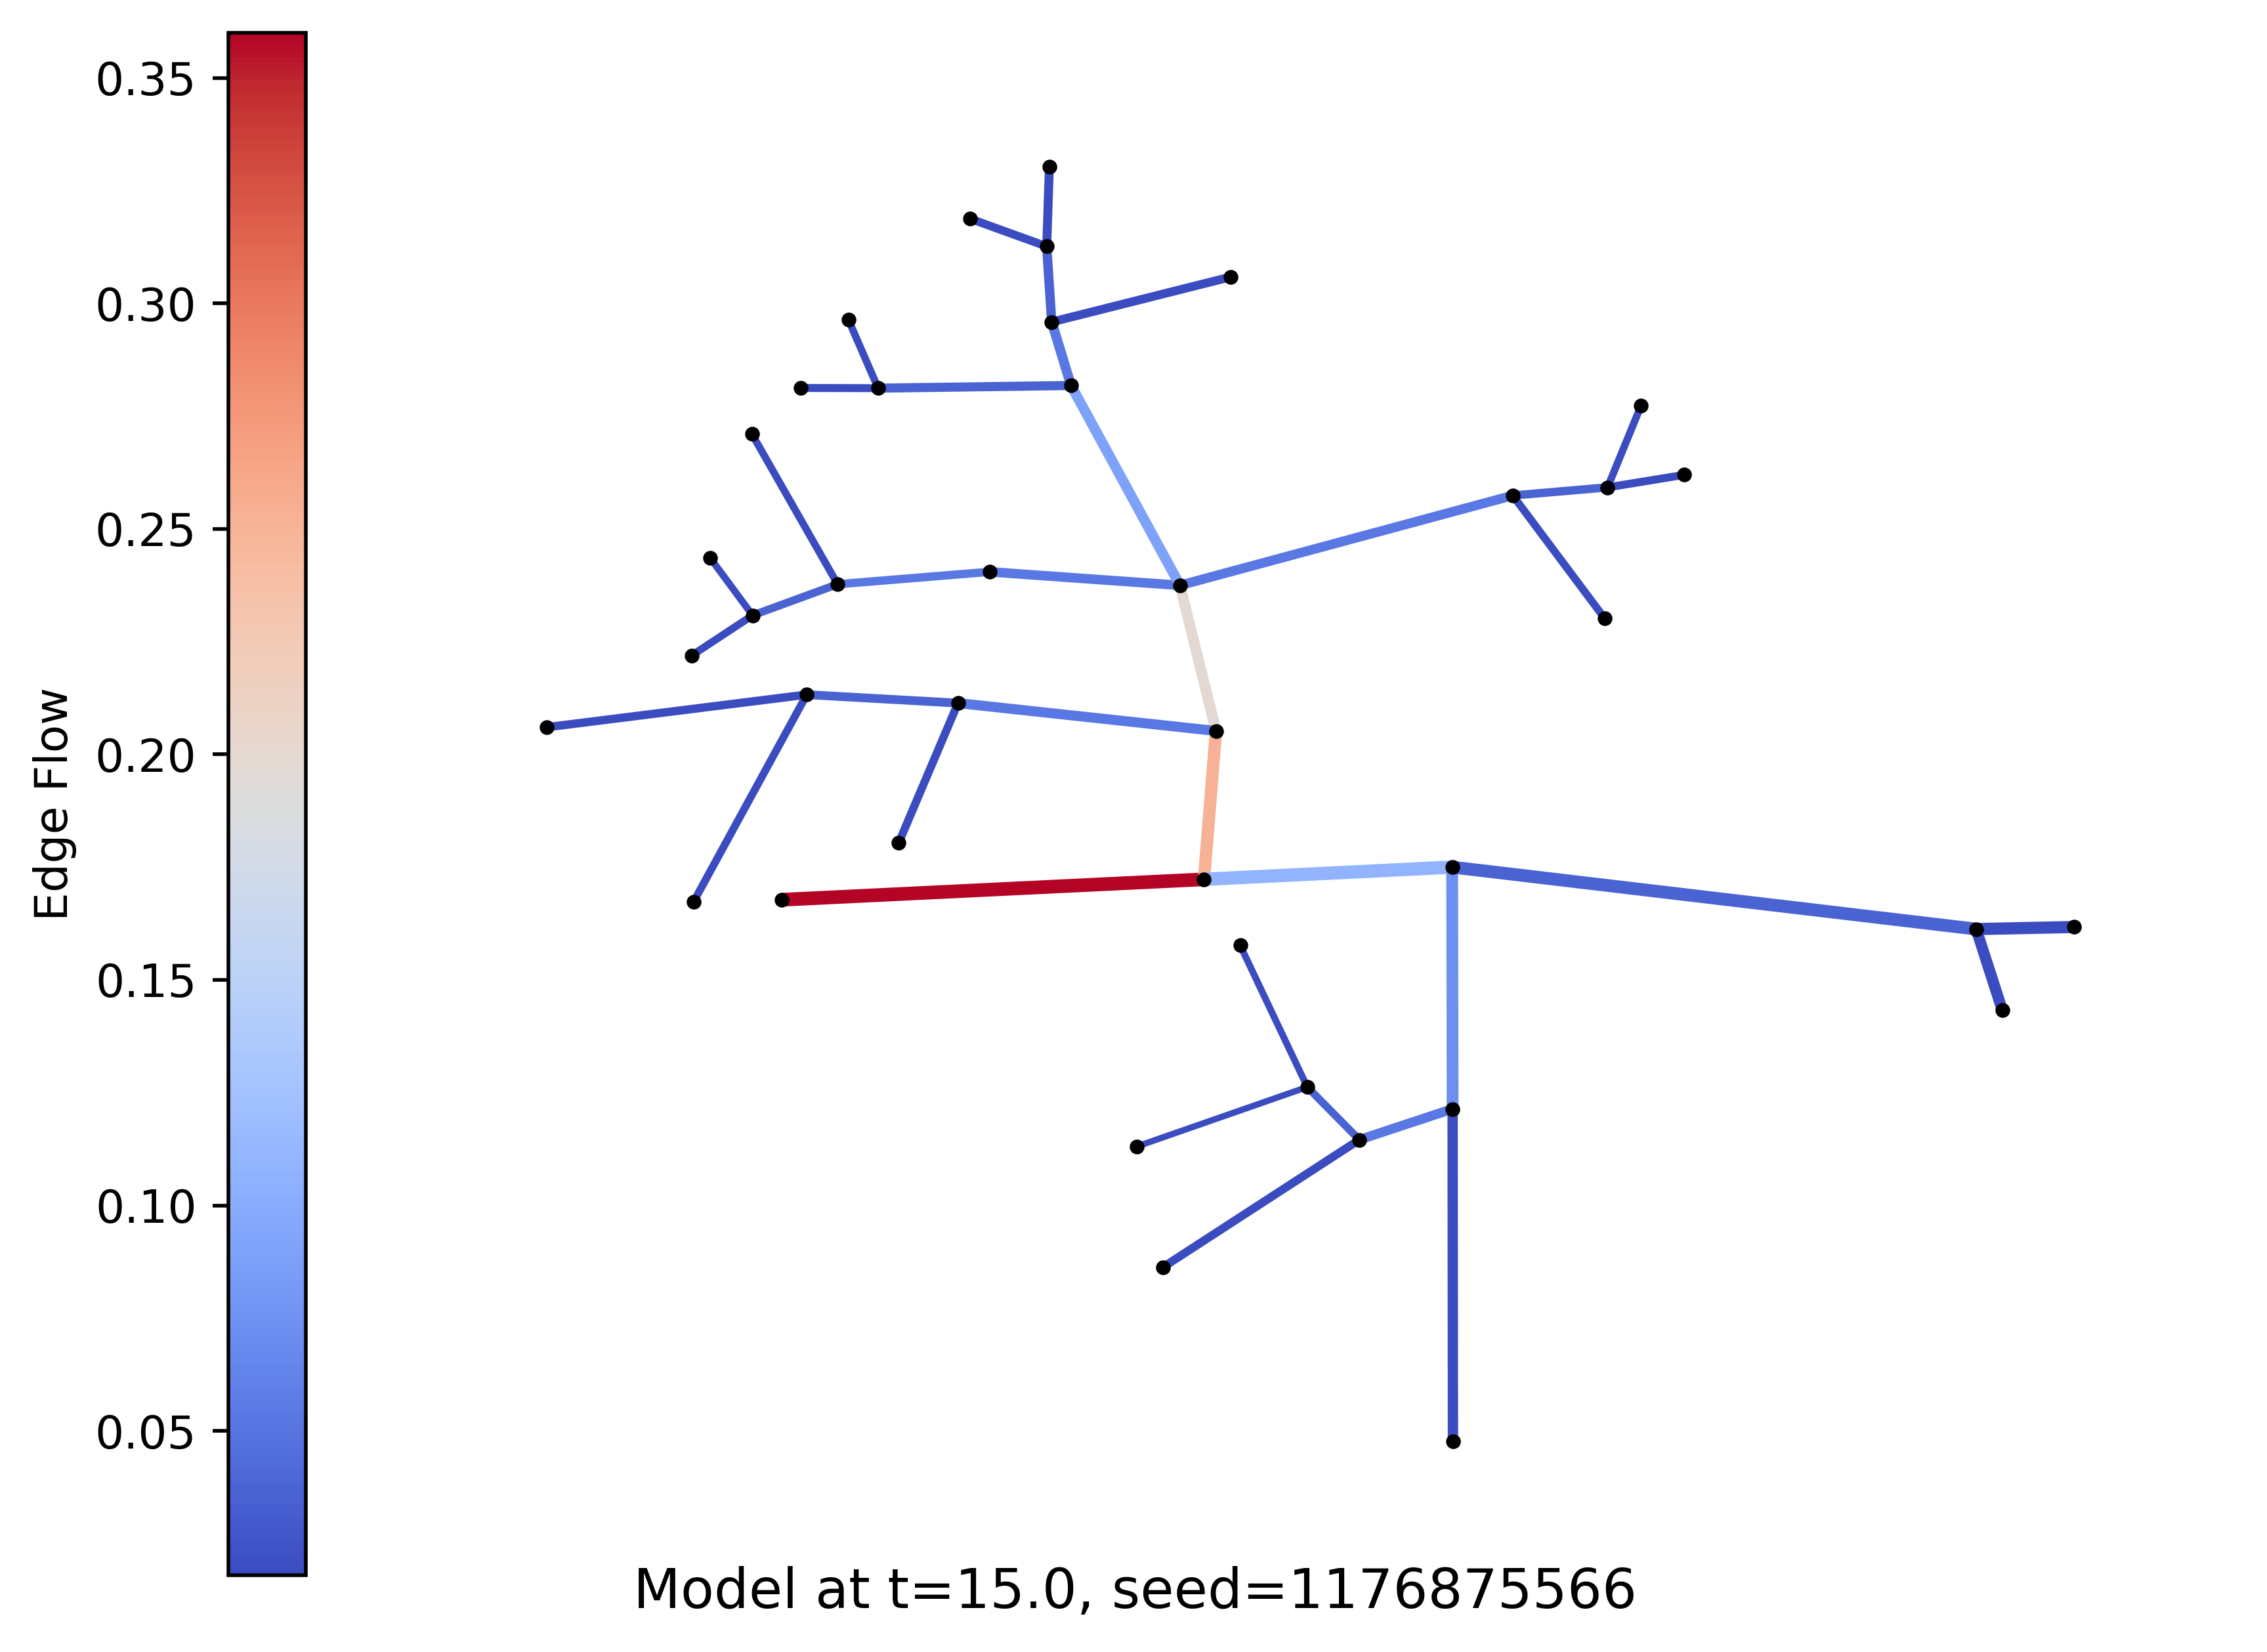

In [26]:
#----- 
# Suppose P_sol and edge_values already computed
node_values = [P_sol[n] for n in G.nodes]  # pressure at each node
edge_values = np.array(Q_annulus)  # or A, K, or Q (length = num_edges)
edge_widths = np.array(B)  # or A, K, or Q (length = num_edges)

# --- NODE COLOR SETUP ---
node_cmap = plt.cm.coolwarm
node_norm = plt.Normalize(vmin=min(node_values), vmax=max(node_values))
node_colors = node_cmap(node_norm(node_values))

# --- EDGE COLOR SETUP ---
edge_cmap = plt.cm.coolwarm
edge_norm = plt.Normalize(vmin=edge_values.min(), vmax=edge_values.max())
edge_colors = edge_cmap(edge_norm(edge_values))

fig, ax = plt.subplots(figsize=(7, 5))

# draw nodes w pressure
nx.draw_networkx_nodes(
    G, pos,
    node_color='black',
    cmap=node_cmap,
    node_size=5,
    ax=ax
)

# draw edges
nx.draw_networkx_edges(
    G, pos,
    edgelist=list(G.edges()),
    edge_color=edge_colors,
    width=edge_widths*3,
    arrows=False,
    ax=ax
)

# edge labels
edge_labels = {edge: f"{val:.2f}" for edge, val in zip(G.edges(), edge_values)}
"""
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_color='black',
    font_size=5,
    ax=ax
)
"""

"""
# node colorbar
sm_nodes = plt.cm.ScalarMappable(cmap=node_cmap, norm=node_norm)
sm_nodes.set_array([])
cbar_nodes = fig.colorbar(sm_nodes, ax=ax, fraction=0.046, pad=0.04)
cbar_nodes.set_label('Node Pressure')
"""

# edge colorbar
sm_edges = plt.cm.ScalarMappable(cmap=edge_cmap, norm=edge_norm)
sm_edges.set_array([])
cbar_edges = fig.colorbar(sm_edges, ax=ax, fraction=0.046, pad=0.04, location = 'left')
cbar_edges.set_label('Edge Flow')


plt.axis('off')
txt_model = "Model at t=" + str(time_elapsed) + ", seed=" +str(seed)
plt.rcParams['figure.dpi'] = 600 # For inline display in notebook
plt.tight_layout()
plt.rcParams['figure.dpi'] = 500 # For inline display in notebook
plt.figtext(0.5, 0.01, txt_model, wrap=True, horizontalalignment='center', fontsize=12)
plt.show()

In [18]:
loop_edge_count = 0
non_loop_edge_count = 0
for i in range(len(edges)):
    if abs(Q_w[i]) > 0.01:
        loop_edge_count += 1
        print(f"Edge {edges[i]} has flow {Q_w[i]}")
    else:
        non_loop_edge_count += 1
        #print(f"Edge {edges[i]} has flow {Q_w[i]}")
print(f"Number of loop edges: {loop_edge_count}")
print(f"Number of non-loop edges: {non_loop_edge_count}")


Number of loop edges: 0
Number of non-loop edges: 39


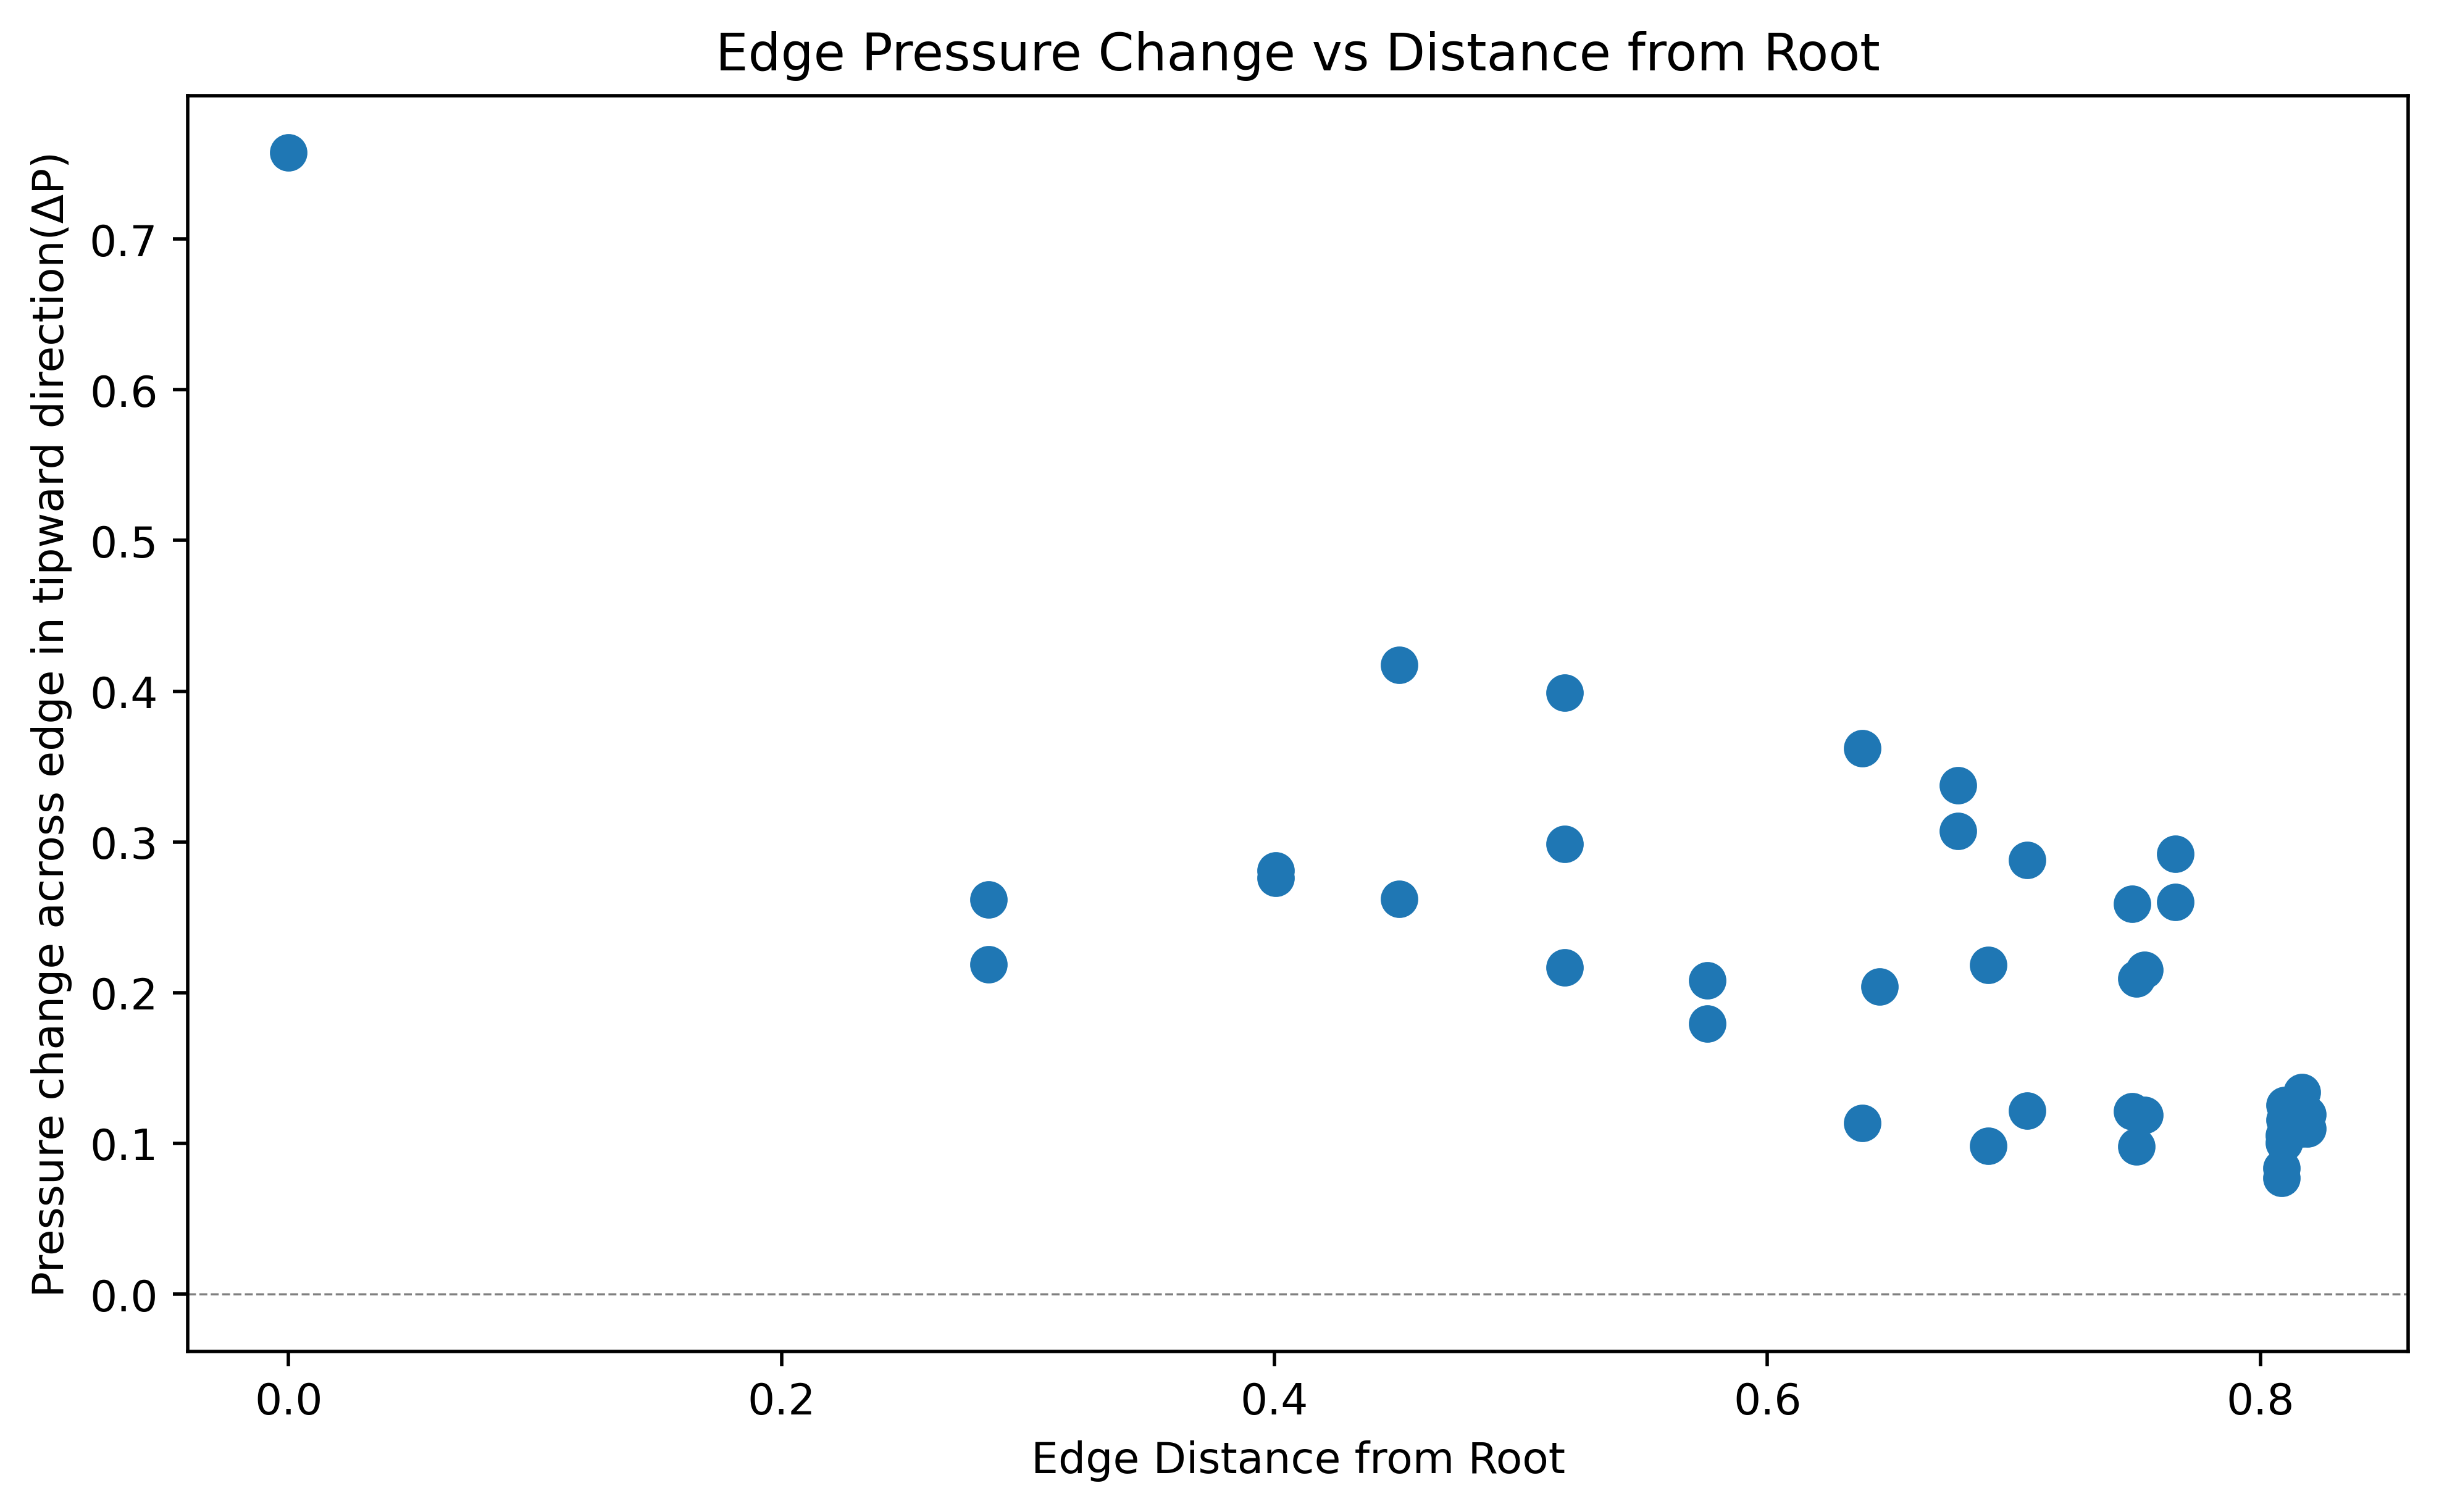

In [19]:
edge_pressures = delta @ P_sol

dist_from_root = nx.shortest_path_length(G, source=0, weight="L")
edge_depth = np.array([dist_from_root[u] for u, v in edges])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(edge_depth, edge_pressures, s=60, zorder=3)

ax.set_xlabel("Edge Distance from Root")
ax.set_ylabel("Pressure change across edge in tipward direction(ΔP)")
ax.set_title("Edge Pressure Change vs Distance from Root")
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
#ax.grid(True, alpha=0.3)
#plt.figtext(0.5, 0.01, txt_model, wrap=True, horizontalalignment='center', fontsize=8)
plt.tight_layout()
plt.show()

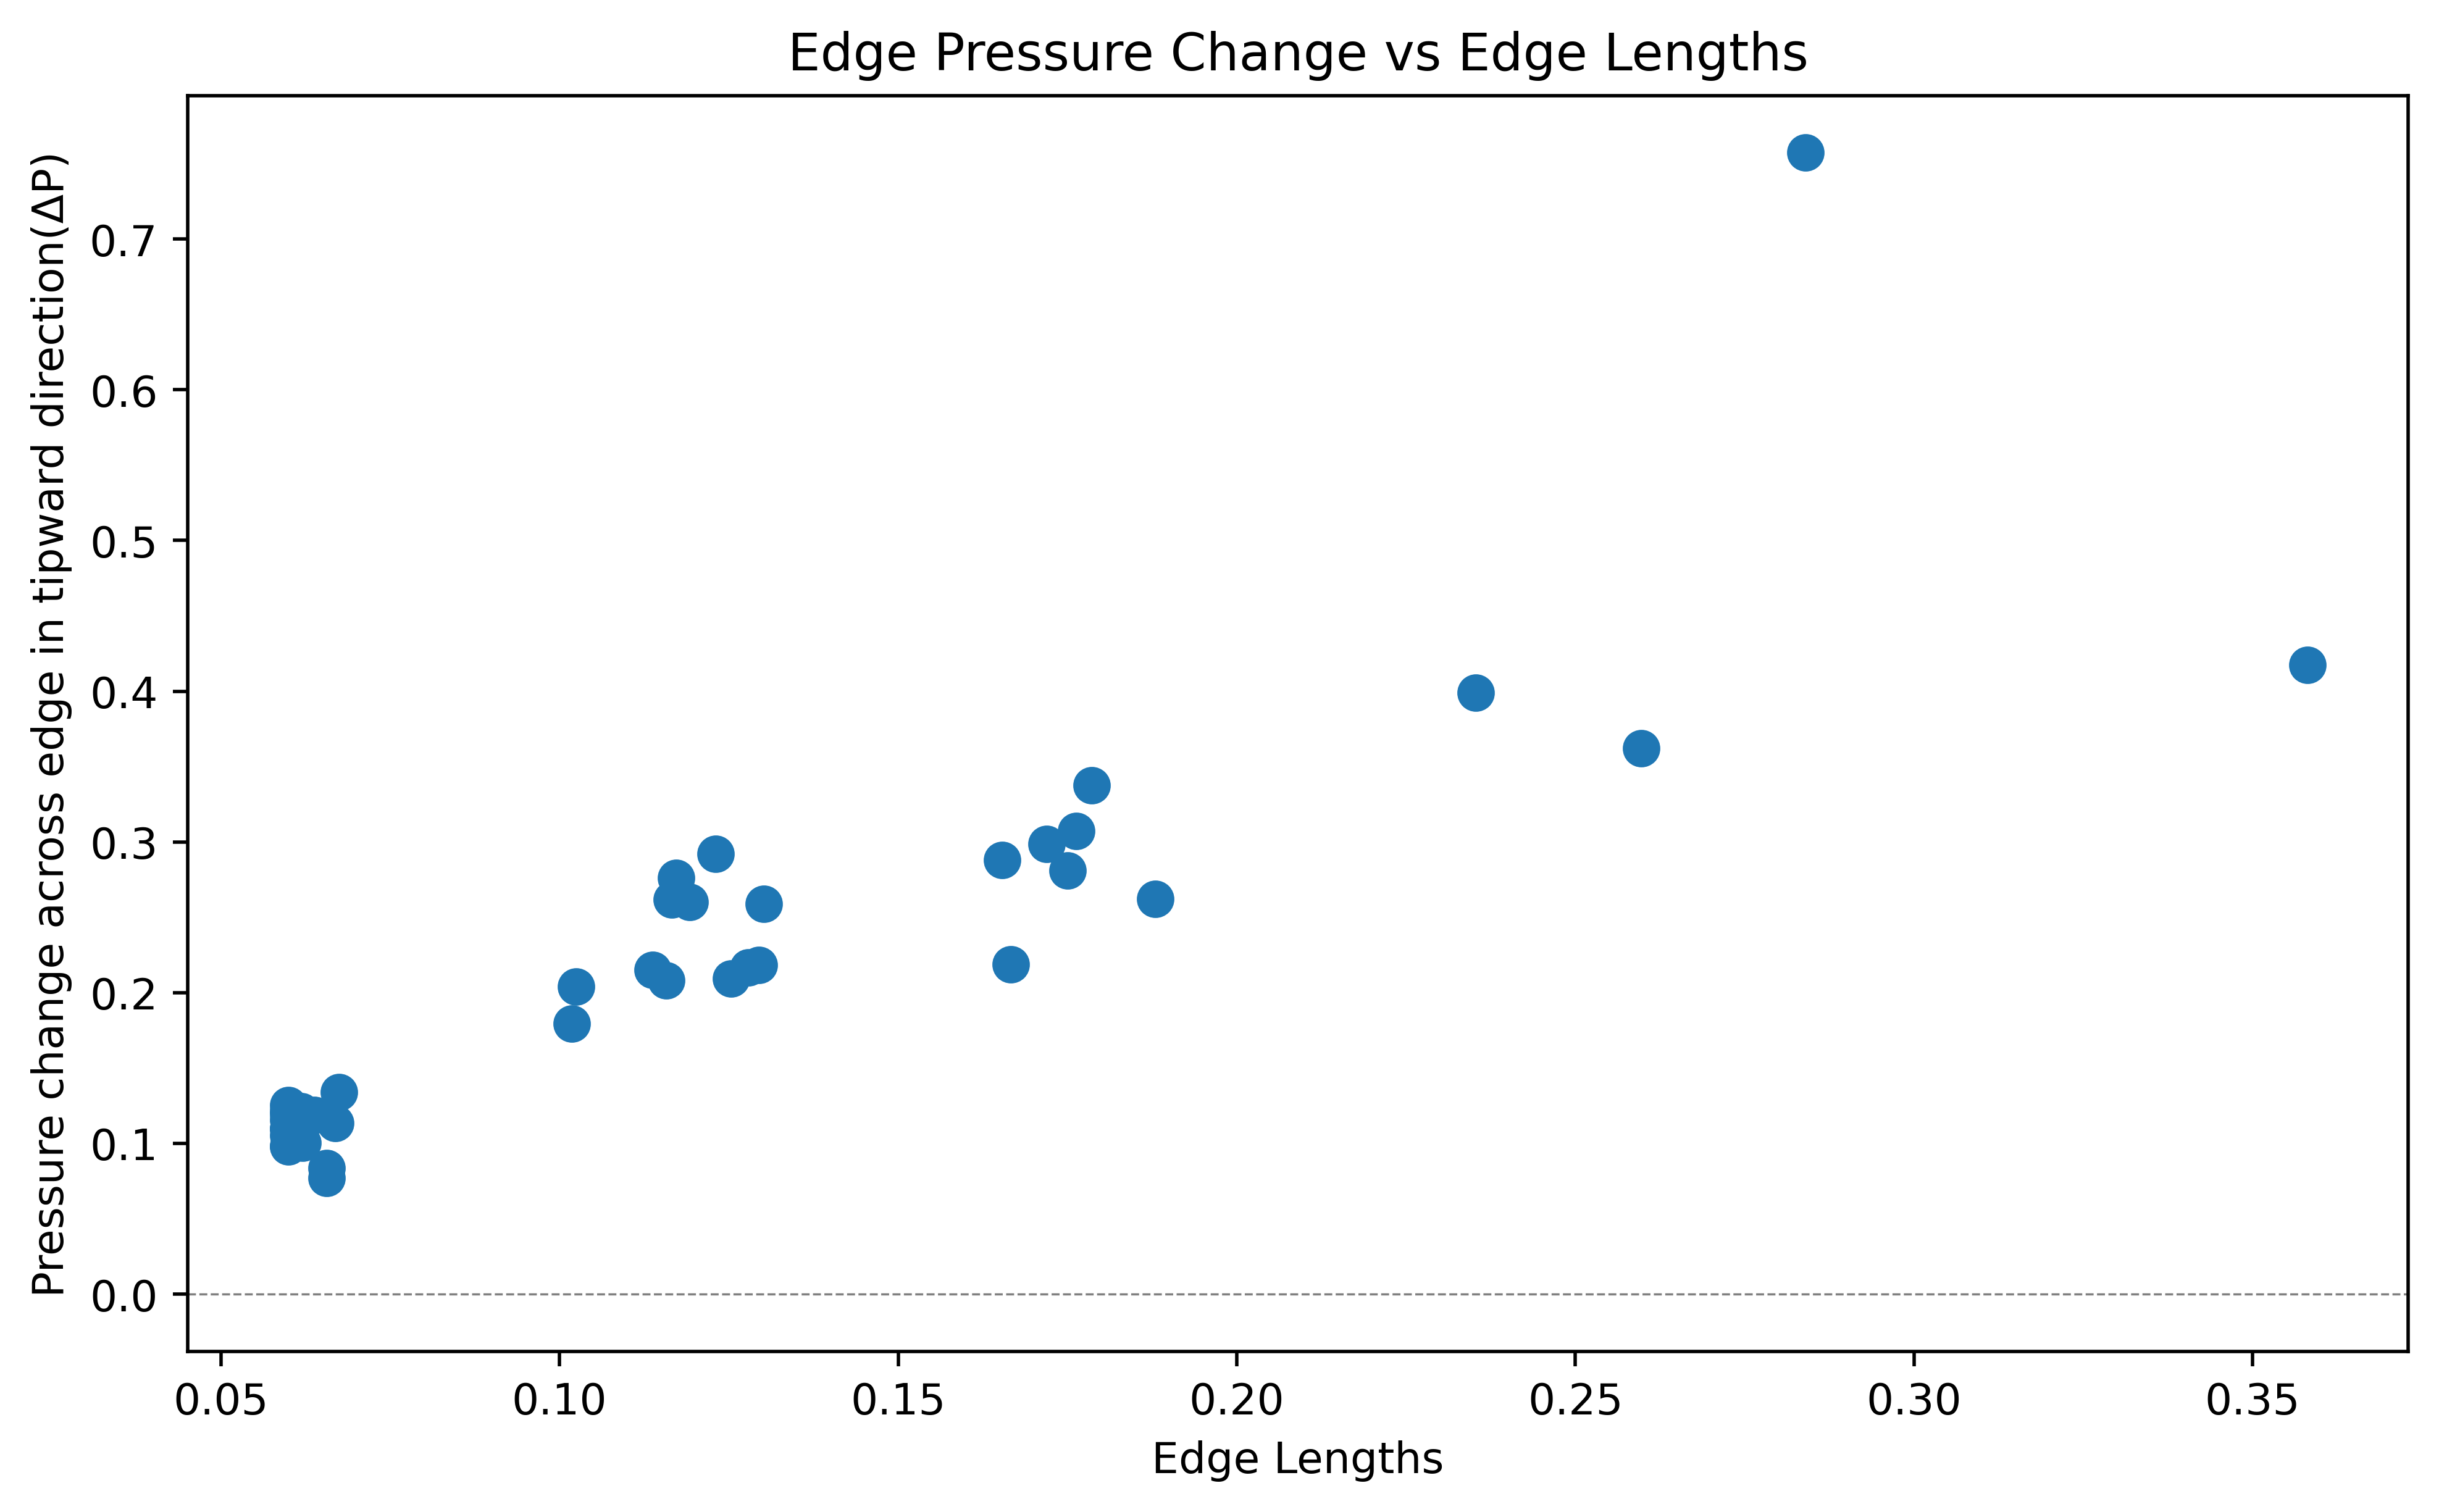

In [20]:

edge_lengths = np.array([G[u][v]["L"] for u, v in edges])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(edge_lengths, edge_pressures, s=60, zorder=3)

ax.set_xlabel("Edge Lengths")
ax.set_ylabel("Pressure change across edge in tipward direction(ΔP)")
ax.set_title("Edge Pressure Change vs Edge Lengths")
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
#ax.grid(True, alpha=0.3)
#plt.figtext(0.5, 0.01, txt_model, wrap=True, horizontalalignment='center', fontsize=8)
plt.tight_layout()
plt.show()

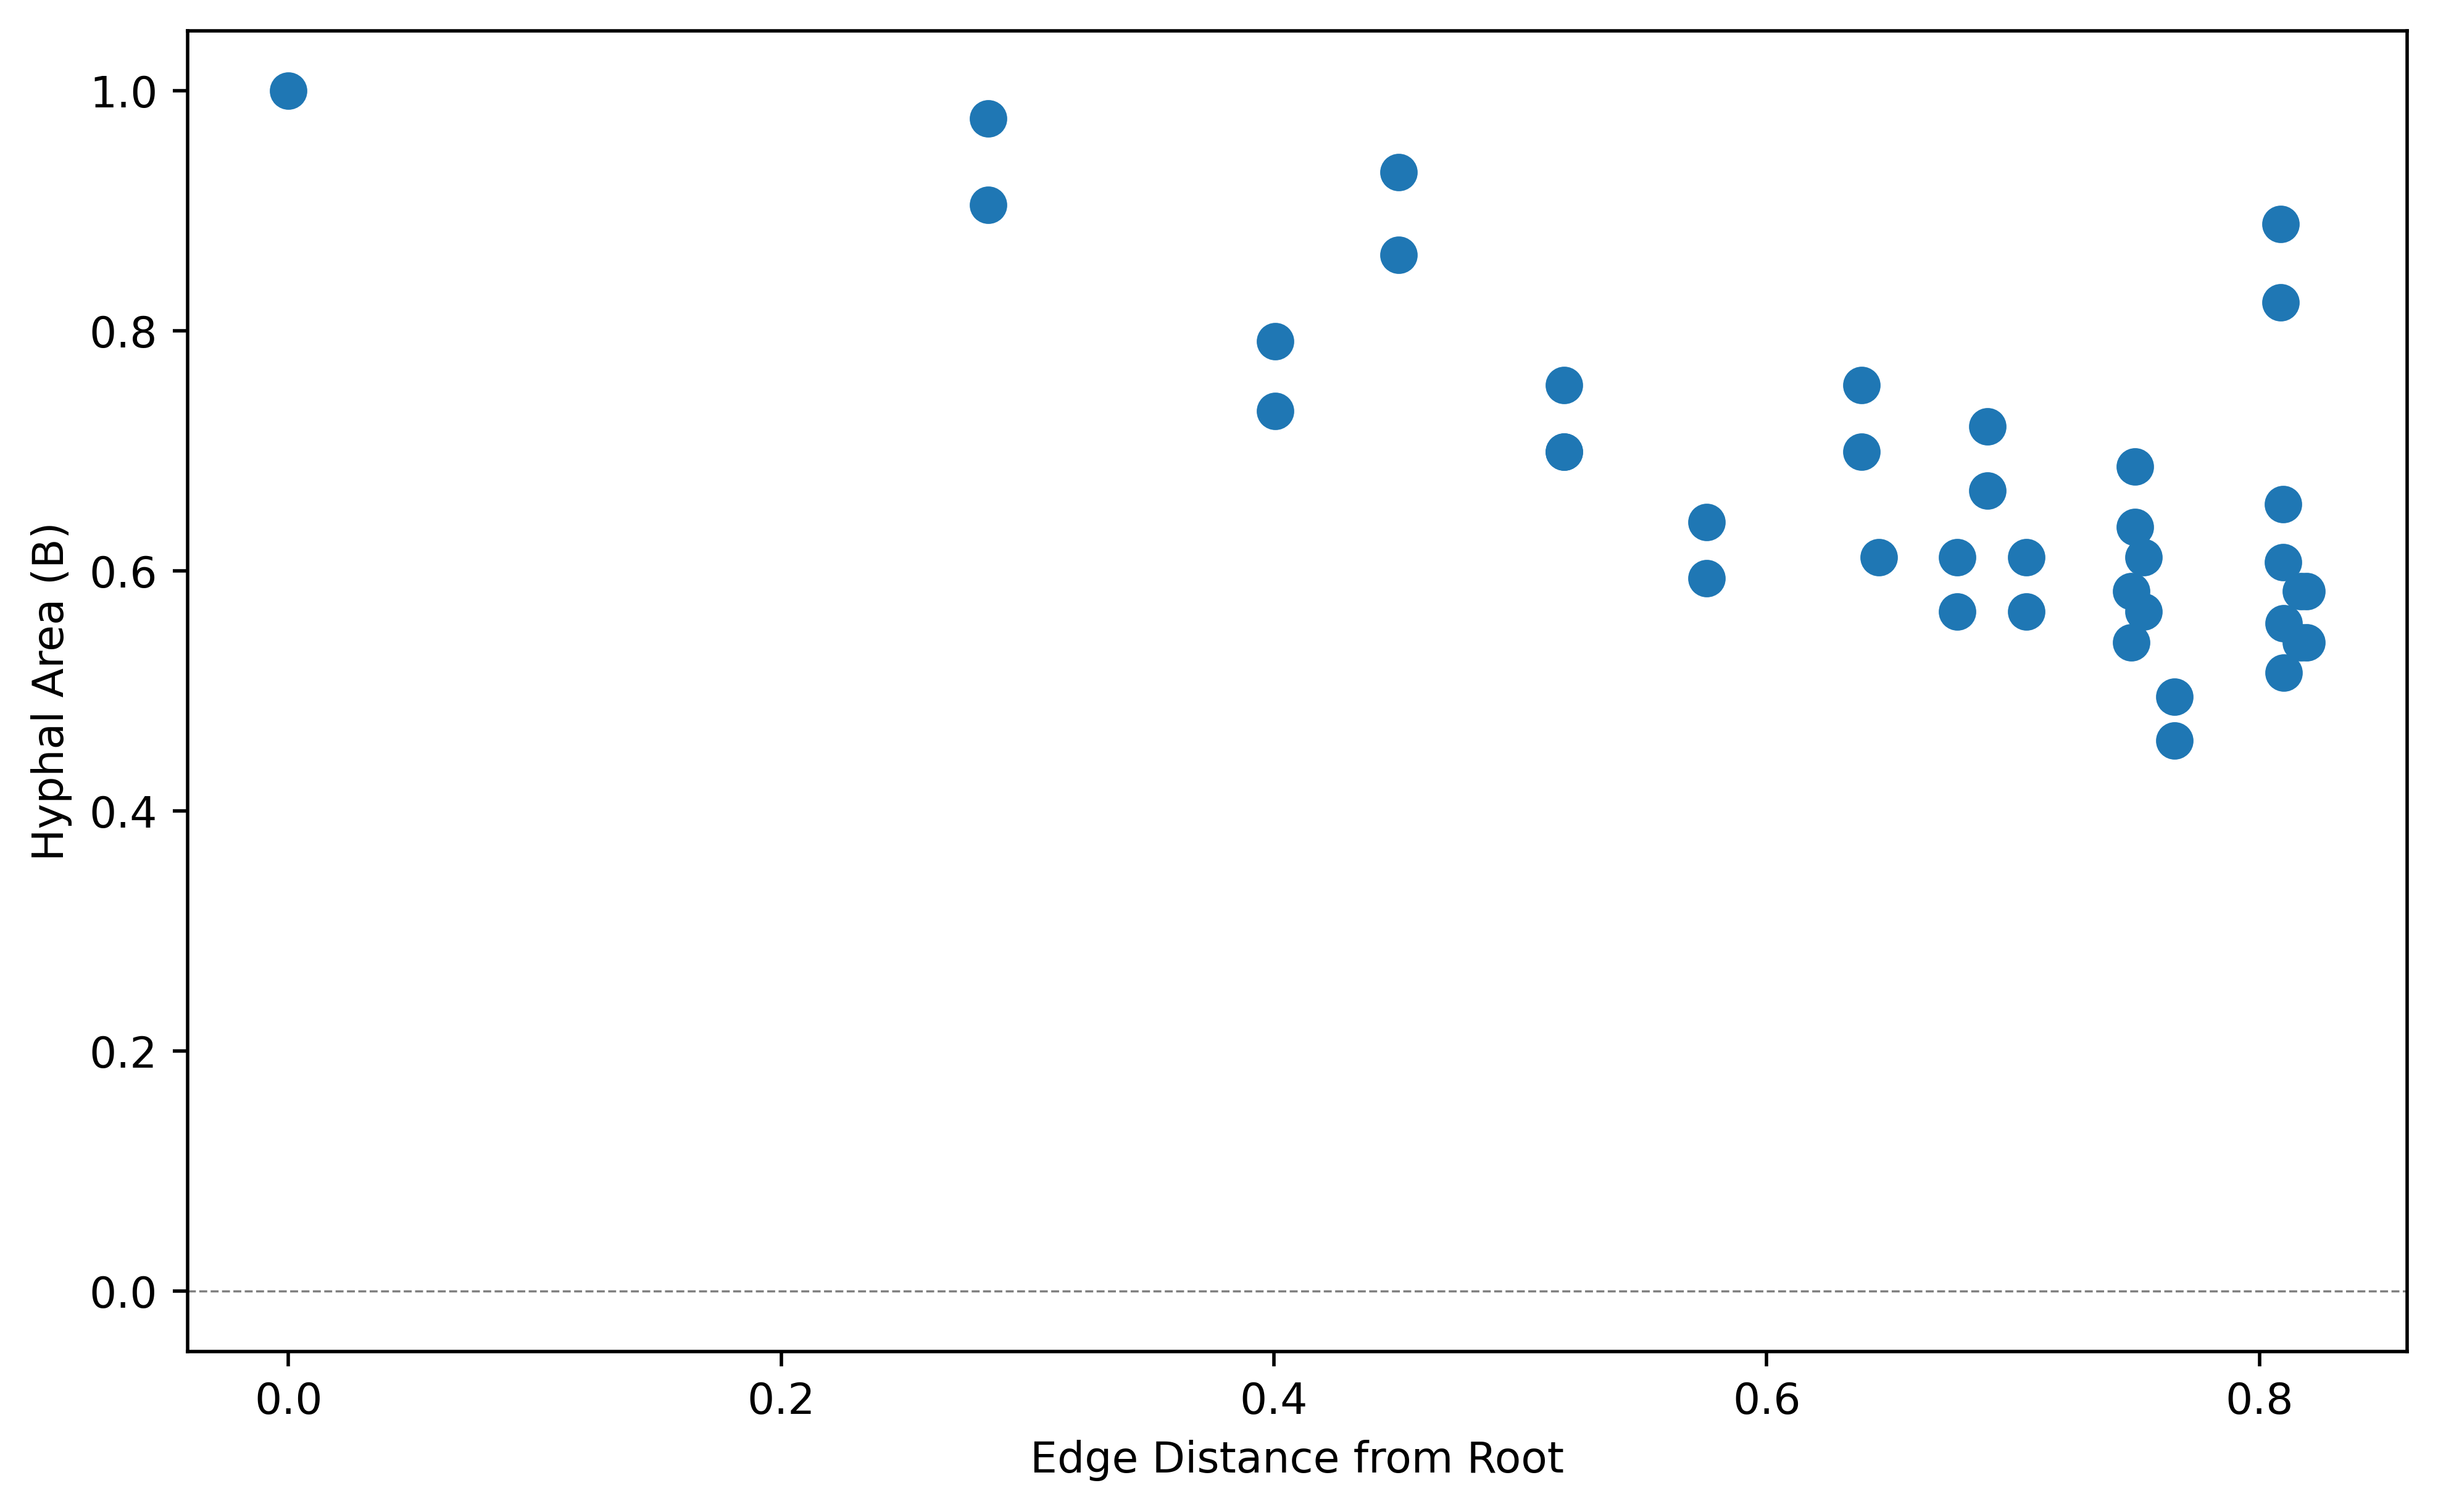

In [21]:


fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(edge_depth, B, s=60, zorder=3)

ax.set_xlabel("Edge Distance from Root")
ax.set_ylabel("Hyphal Area (B)")
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
#ax.grid(True, alpha=0.3)
#plt.figtext(0.5, 0.01, txt_model, wrap=True, horizontalalignment='center', fontsize=8)
plt.tight_layout()
plt.show()

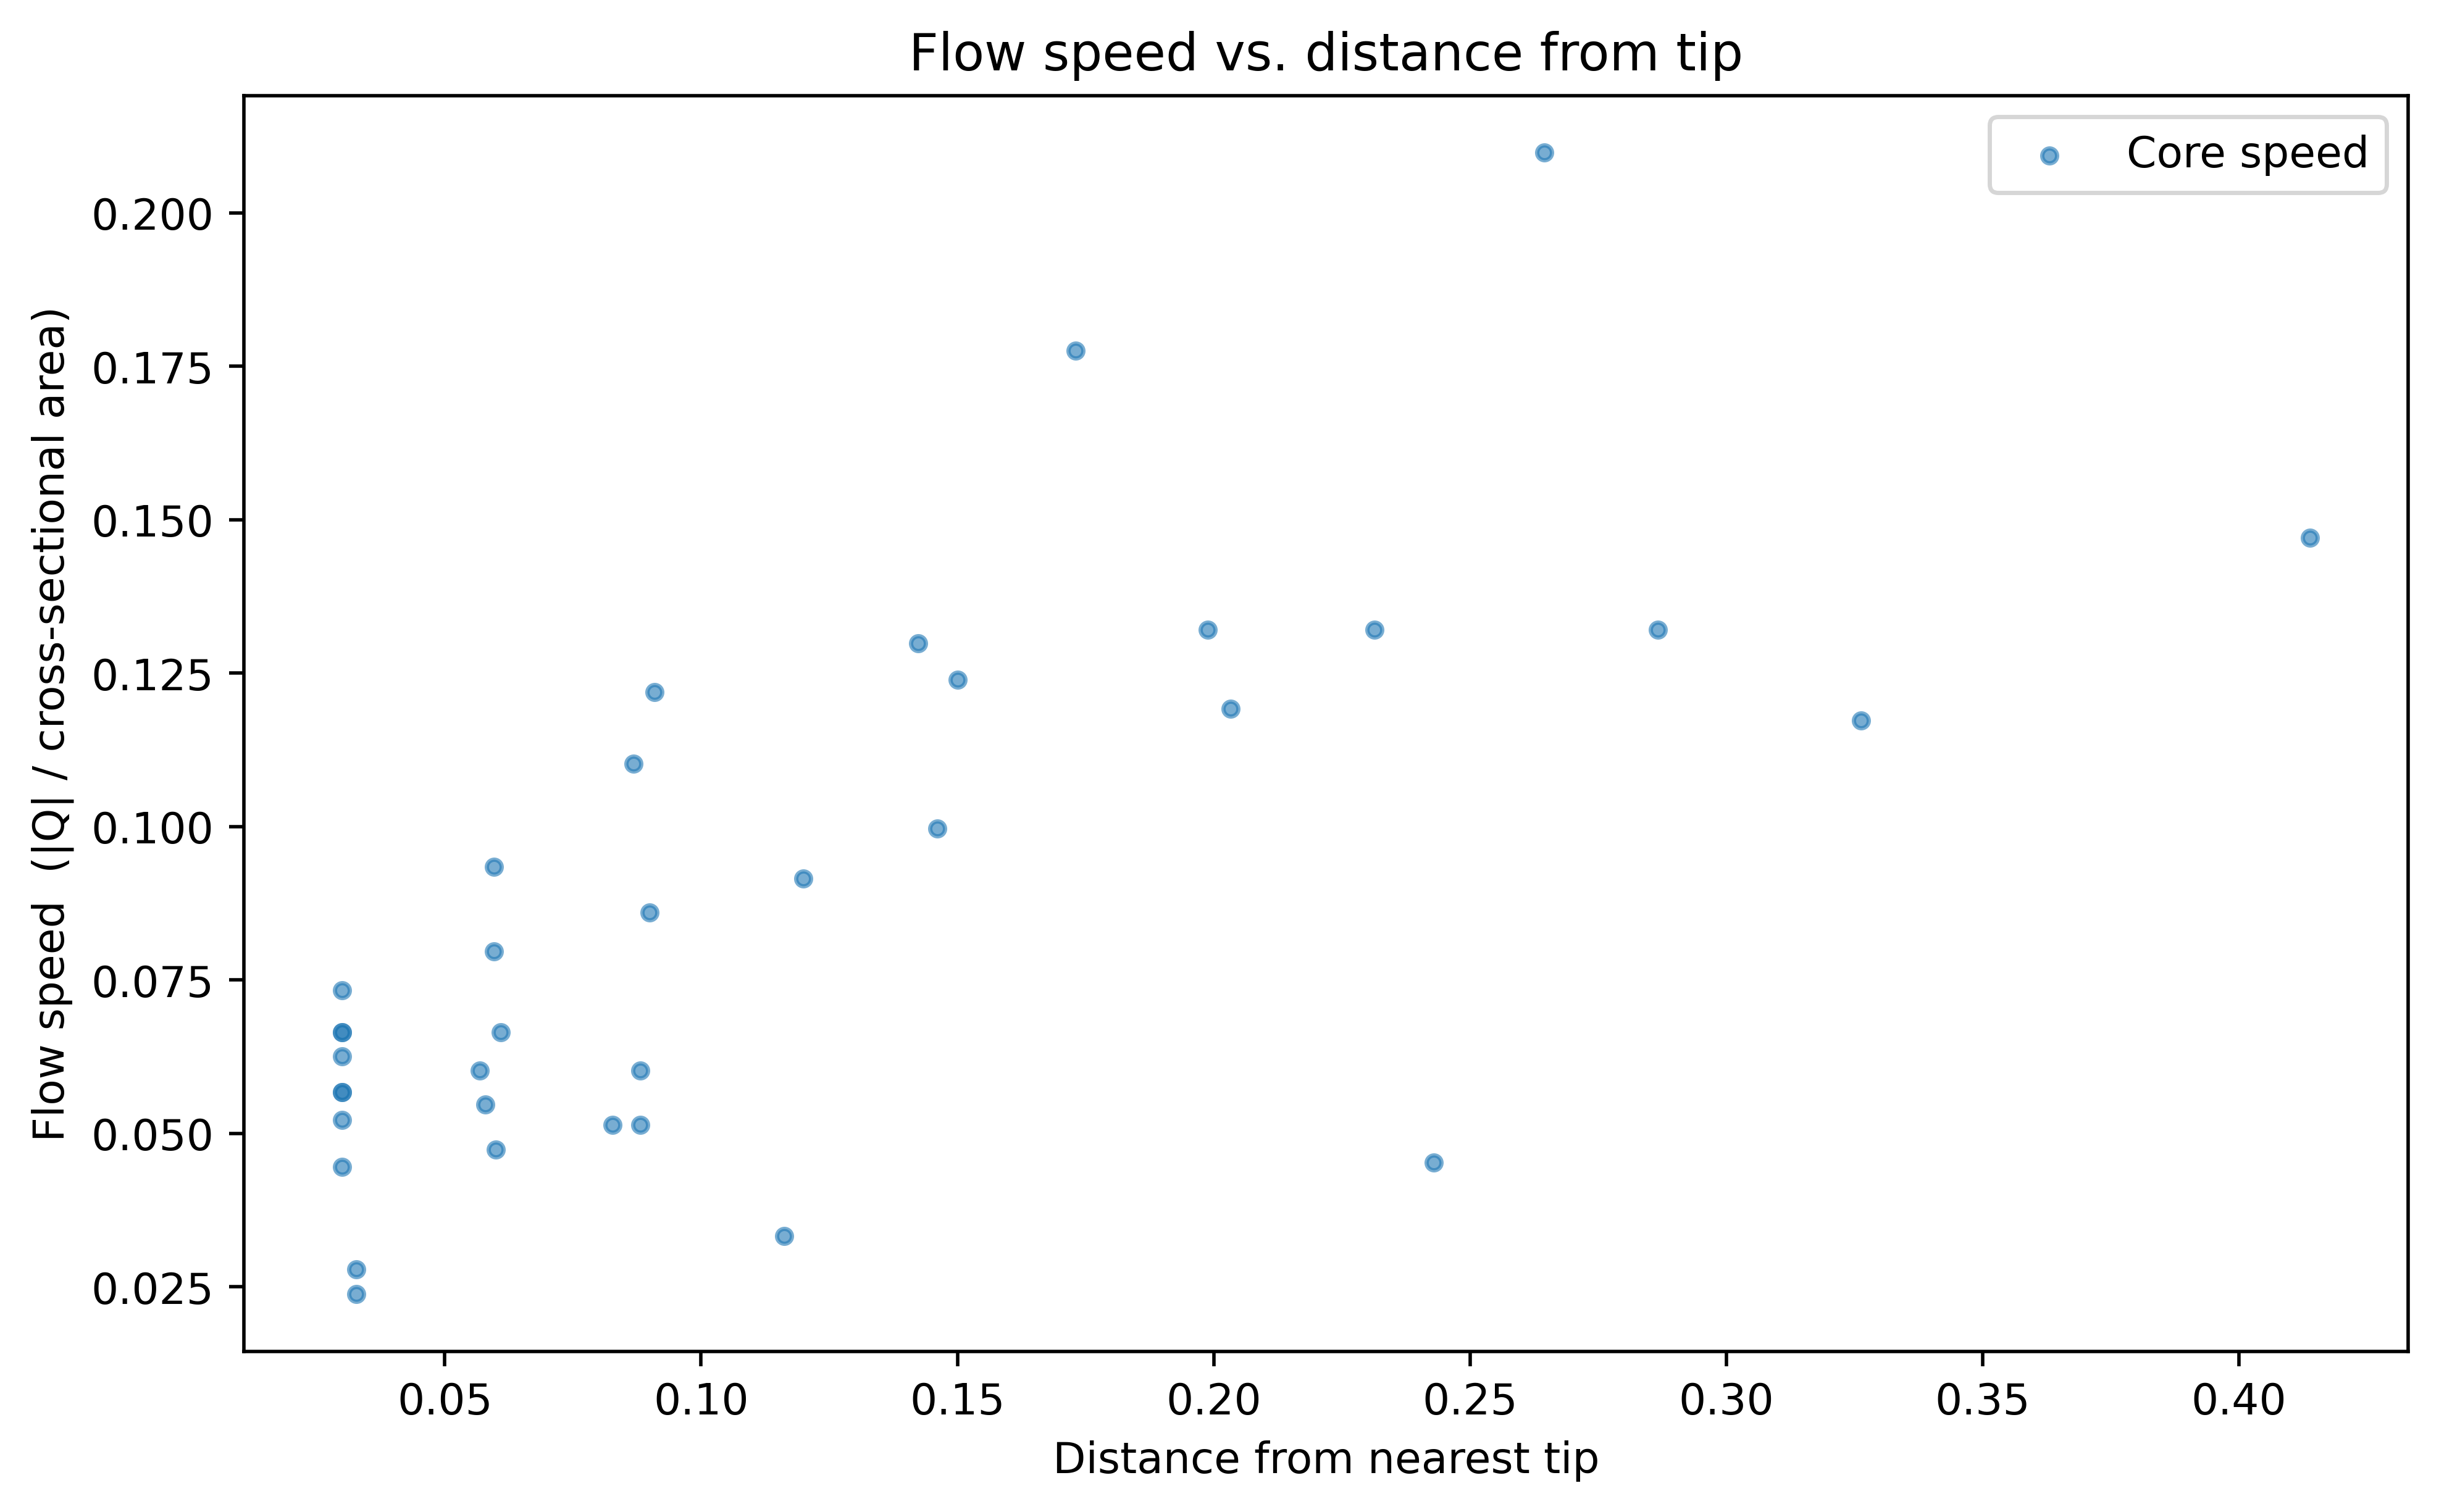

Filtered 3 outlier(s) out of 39 edges


In [22]:
from collections import deque

leaves = [n for n in G.nodes() if G.out_degree(n) == 0]
G_undir = G.to_undirected()
dist_from_tip = {n: float("inf") for n in G.nodes()}
queue = deque()
for lf in leaves:
    dist_from_tip[lf] = 0.0
    queue.append(lf)
while queue:
    u = queue.popleft()
    for v in G_undir.neighbors(u):
        if G.has_edge(u, v):
            L_uv = G[u][v]["L"]
        else:
            L_uv = G[v][u]["L"]
        candidate = dist_from_tip[u] + L_uv
        if candidate < dist_from_tip[v]:
            dist_from_tip[v] = candidate
            queue.append(v)


edge_dist = []
speed_core = []
speed_annulus = []


for idx, (u, v) in enumerate(edges):
    d_mid = (dist_from_tip[u] + dist_from_tip[v]) / 2.0
    edge_dist.append(d_mid)
    a = A[idx]
    b = B[idx]
    area_core = max(a**2, 1e-12)
    area_annulus = max(b**2 - a**2, 1e-12)
    speed_core.append(abs(Q_core[idx]) / area_core)
    speed_annulus.append(abs(Q_annulus[idx]) / area_annulus)


edge_dist = np.array(edge_dist)
speed_core = np.array(speed_core)
speed_annulus = np.array(speed_annulus)

def iqr_mask(arr, factor=1.5):
    q1, q3 = np.percentile(arr, 25), np.percentile(arr, 75)
    iqr = q3 - q1
    return arr <= q3 + factor * iqr

mask = iqr_mask(speed_core) & iqr_mask(speed_annulus)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(edge_dist[mask], speed_core[mask], s=12, alpha=0.6, label="Core speed")
#ax.scatter(edge_dist[mask], speed_annulus[mask], s=12, alpha=0.6, label="Annular speed")
ax.set_xlabel("Distance from nearest tip")
ax.set_ylabel("Flow speed  (|Q| / cross-sectional area)")
ax.set_title("Flow speed vs. distance from tip")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Filtered {(~mask).sum()} outlier(s) out of {len(mask)} edges")

/var/folders/hv/8_nq957s7r91cy1ppp9ns07m0000gn/T/ipykernel_57129/719872890.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


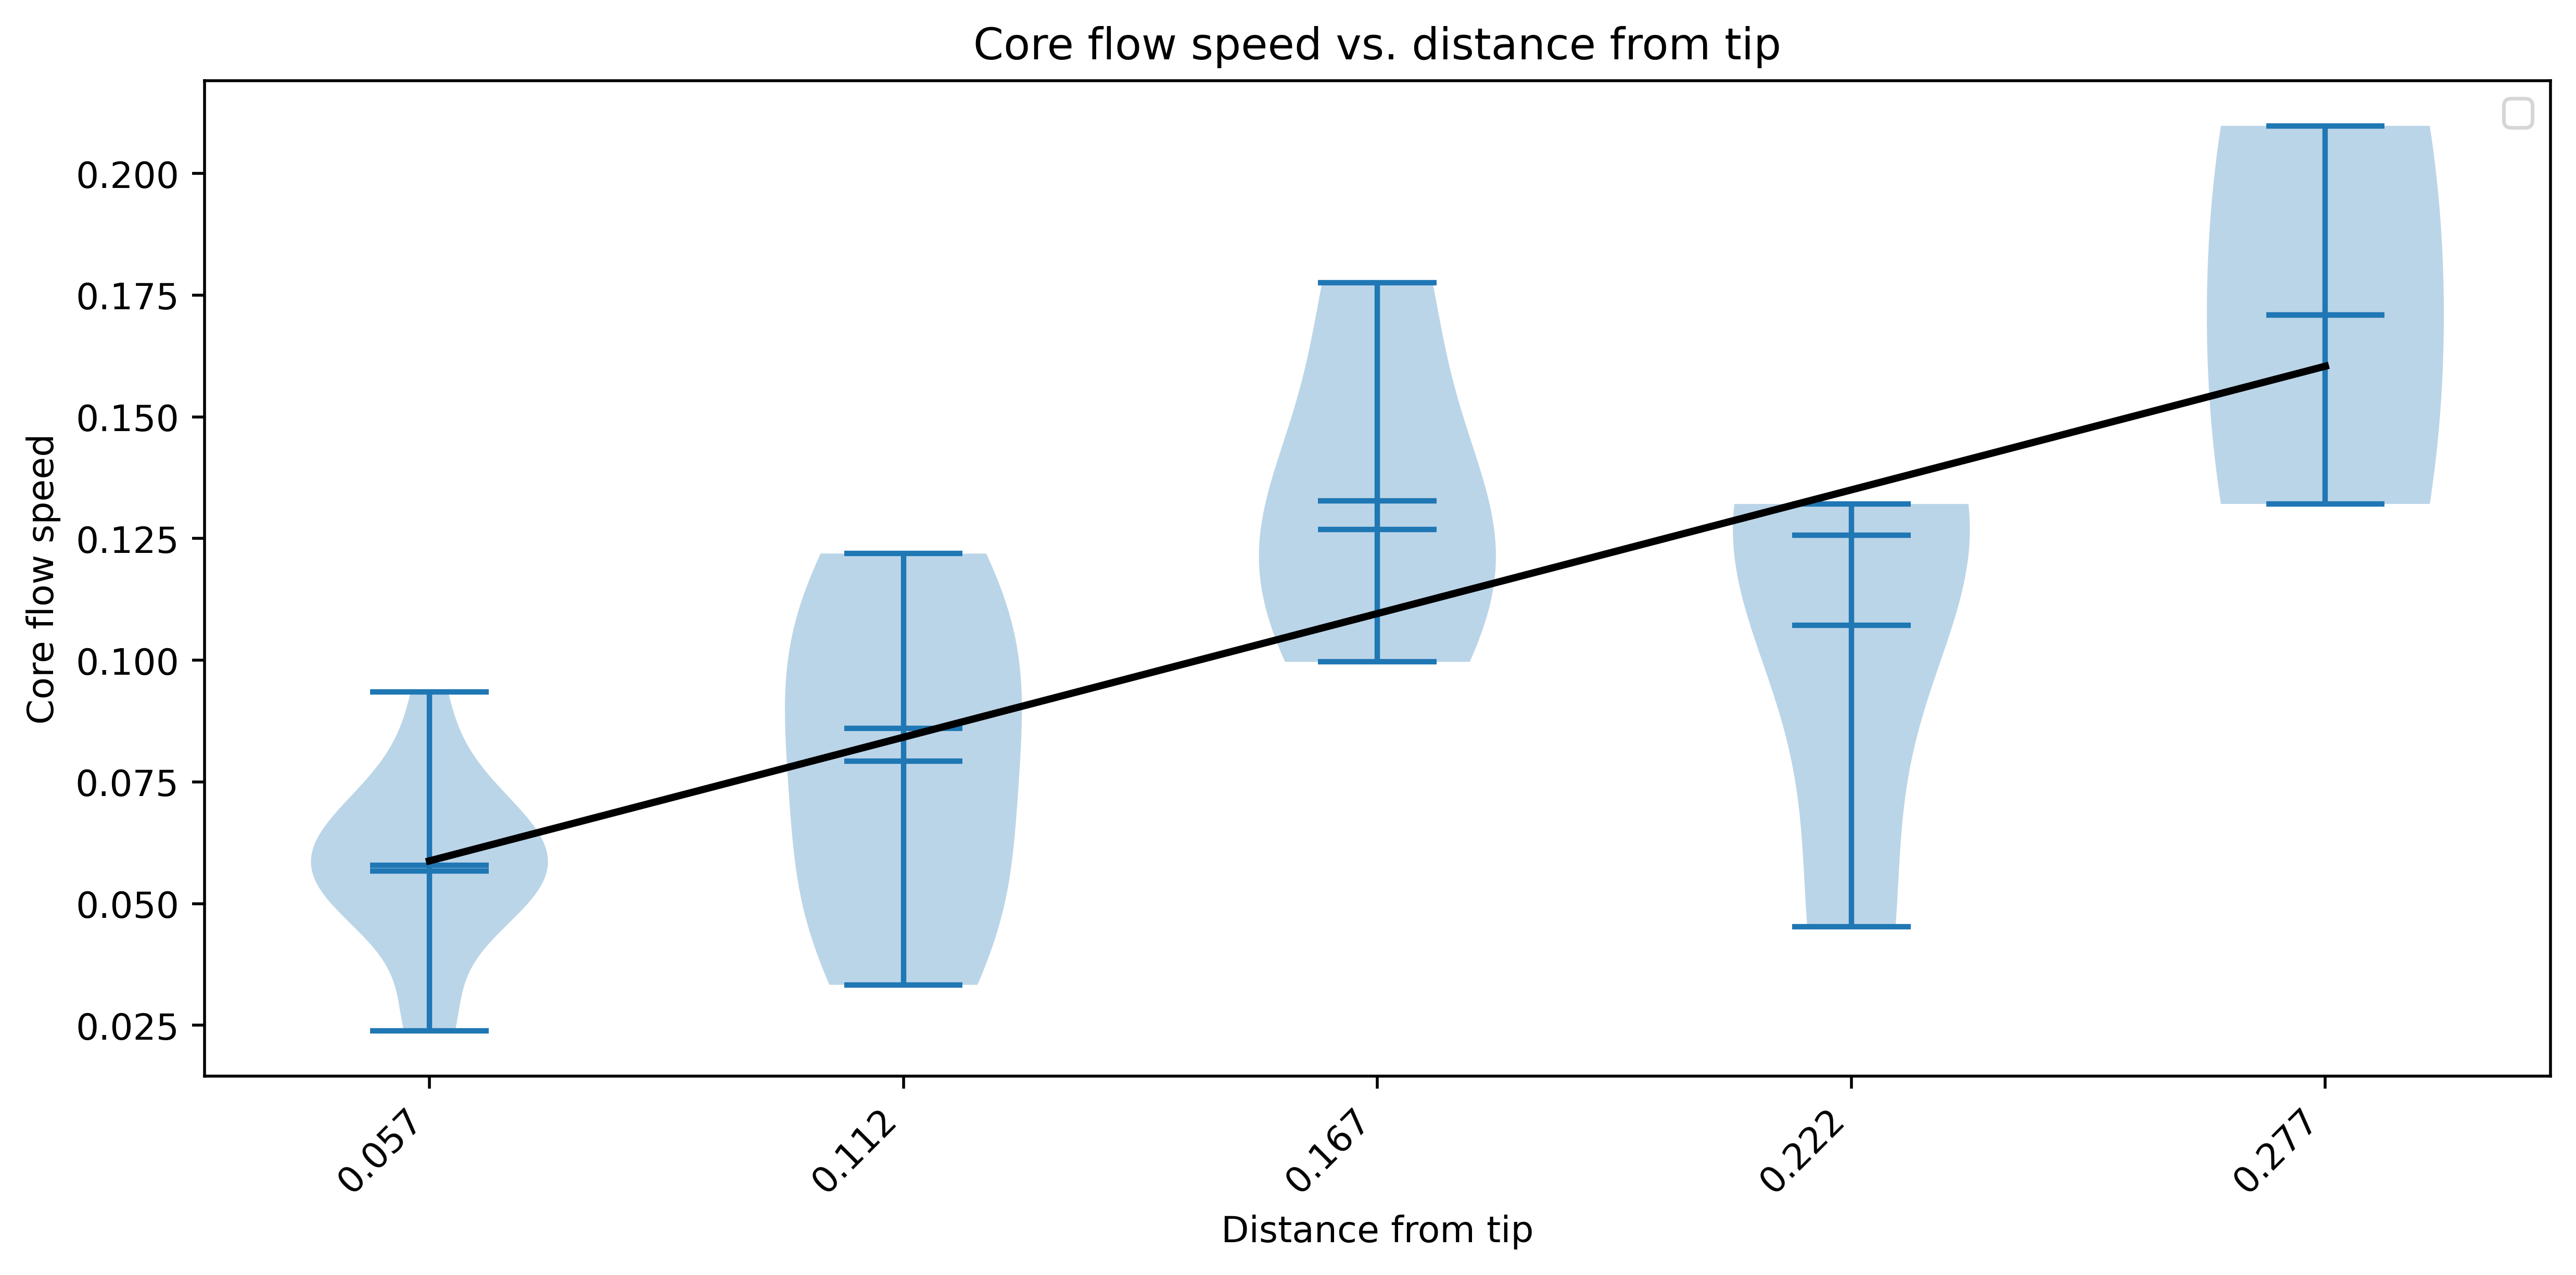

Bins with ≥2 edges: 5 / 7
Linear fit: speed = 0.025407 * bin + 0.058782


In [23]:
n_bins = 7
dist_filt = edge_dist[mask]
speed_filt = speed_core[mask]

bin_edges = np.linspace(dist_filt.min(), dist_filt.max(), n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_indices = np.digitize(dist_filt, bin_edges) - 1
bin_indices = np.clip(bin_indices, 0, n_bins - 1)

bin_data = [speed_filt[bin_indices == i] for i in range(n_bins)]
bin_data = [b for b in bin_data if len(b) >= 2]

fig, ax = plt.subplots(figsize=(10, 5))
parts = ax.violinplot(bin_data, positions=range(len(bin_data)),
                      showmeans=True, showmedians=True)
bin_means = np.array([b.mean() for b in bin_data])
x_pos = np.arange(len(bin_data))
coeffs = np.polyfit(x_pos, bin_means, 1)
ax.plot(x_pos, np.polyval(coeffs, x_pos), color="black", linewidth=2)
ax.legend()

ax.set_xticks(range(len(bin_data)))
ax.set_xticklabels([f"{bin_centers[i]:.3f}" for i in range(len(bin_data))],
                   rotation=45, ha="right")
ax.set_xlabel("Distance from tip")
ax.set_ylabel("Core flow speed")
ax.set_title("Core flow speed vs. distance from tip")
plt.tight_layout()
plt.show()
print(f"Bins with ≥2 edges: {len(bin_data)} / {n_bins}")
print(f"Linear fit: speed = {coeffs[0]:.6f} * bin + {coeffs[1]:.6f}")